# Simulating community dynamics

This notebook explains how you can create a consumer resource model, simulate its dynamics, and calculate its community properties (like the consumer survival fraction) and stability.

In [3]:
# load modules

from matplotlib import pyplot as plt
import numpy as np
import os
import sys

# load in consumer-resource model modules
module_path = os.path.abspath(os.path.join('..', 'consumer_resource_modules - Copy'))
# Add to sys.path if not already present
if module_path not in sys.path: sys.path.append(module_path)
    
from models import Consumer_Resource_Model
from community_level_properties import max_le

In [4]:
%load_ext autoreload
%autoreload 2

## Create a consumer-resource model community

We are going to create a consumer-resource model with $S$ consumers and $M$ externally-supplied resources.
The dynamics of resource $\alpha$ $(R_\alpha)$ and consumer $i$ $(N_i)$ over time are described by the following ordinary differential equations:

\begin{align*}
\dfrac{\mathrm{d} R_\alpha}{\mathrm{d} t} &= o_\alpha - b_\alpha R_\alpha - \sum_{i=1}^S c_{i \alpha} N_i,
\\
\dfrac{\mathrm{d} N_i}{\mathrm{d} t} &= N_i \left[\sum_{\alpha=1}^M y_{i \alpha} c_{i \alpha} R_\alpha - d_i \right].
\end{align*}

- $o_\alpha$ is the external resource influx rate
- $b_\alpha$ is the resource outflux rate or intrinsic resource growth rate
- $c_{i \alpha}$ is the per-capita consumption rate of resource $\alpha$ by consumer $i$
- $y_{i \alpha}$ is the yield conversion factor, or how efficiently consumer $i$ converts resource $\alpha$ into biomass
  - So the per-capita growth rate $g_{i \alpha} = y_{i \alpha} c_{i \alpha}$
- $d_i$ is the per-capita death rate of consumer $i$

I want to sample my parameters from the following normal distributions (first entry = mean, second = standard deviation):

- $o_\alpha \sim \text{Normal}(\mu_o,\sigma_o)$
- $b_\alpha \sim \text{Normal}(\mu_b, \sigma_b)$
- $c_{i \alpha} \sim \text{Normal}(\mu_c/M, \sigma_c/\sqrt{M})$
- $y_{i \alpha} \sim \text{Normal}(\mu_y, \sigma_y)$
- $d_i \sim \text{Normal}(\mu_d, \sigma_d)$

We scale the consumption rates by the resource pool size to ensure a consumer's total consumption and growth rate does not vary with the number of resources $M$. 
This is a common assumption made when parametrising models of large communities as it ensures consumers cannot grow infinitely fast as the number of resources can increase.
(It could capture, for example, similar resources following into the same metabolic pathway in a cel, so the total resource consumption rate is capped by the metabolic flux within that cell.)

To create the consumer-resource model, I will first define the statistical properties of model parameters, or the means and variances of the normal distributions defined before:
- I will set the number or diversity of resources, also known as the resource pool size $M$, to 75. I will also set the initial number of consumers, or consumer pool size $S$ to 75
- For $o_\alpha$: $\mu_o = 1, \ \sigma_o = 0$
- For $b_\alpha$: $\mu_o = 1, \ \sigma_b = 0$
- For $c_{i \alpha}$:, $\mu_c = 50, \ \sigma_c = 1.6 \ \rho = 1$
- For $y_{i \alpha}$:, $\mu_y = 1, \ \sigma_y = 0.13$
- For $d_i$: $\mu_d = 1, \ \sigma_d = 0$

I'm going to define them in a dictionary for ease:

In [5]:
parameters = dict(M = 75, S = 75,
                  mu_b = 1, sigma_b = 0,
                  mu_o = 1, sigma_o = 0,
                  mu_c = 50, sigma_c = 1.6,
                  mu_y = 1, sigma_y = 0.13,
                  mu_d = 1, sigma_d = 0)

Now, I will create a Consumer_Resource_Model object.
The first argument is a string instructing the function on the type of model to construct (in this case we want to create a model where resources are externally-supplied).
The second argument is a list of your resource and consumer pool sizes

In [6]:
# I'm going to store my model parameters (the statistical properties of the resource and consumer pool) in a dictionary for ease

# Initiate community
community = Consumer_Resource_Model(model = "Externally-supplied resources", # model type
                                    pool_sizes = [parameters['M'], parameters['S']]) # pool sizes

Then, you call the *growth_consumption_rates* and *model_specific_rates* methods to generate the model parameters from their respective distributions:

In [7]:
# generate consumption and growth rates
# (this function assumes rates are normally distributed)
community.growth_consumption_rates(method = 'growth function of consumption', # this determines how growth and consumption rates are coupled
                                   mu_c = parameters['mu_c']/parameters['M'], #  parameters for consumption rates
                                   sigma_c = parameters['sigma_c']/np.sqrt(parameters['M']),
                                   mu_g = parameters['mu_y'], # parameters for yield conversion factors
                                   sigma_g = parameters['sigma_y'])

# generate death rates and intrinsic resource growth rates
community.model_specific_rates(influx_method = "normal", # generate rates from a normal distribution
                               influx_args = {'mu' : parameters['mu_o'], 'sigma' : parameters['sigma_o']}, # supply mean and variances for normal distribution
                               outflux_method = "normal", # repeat for outflux rates
                               outflux_args = {'mu' : parameters['mu_b'], 'sigma' : parameters['sigma_b']},
                               death_method = "normal", # repeat for death rates
                               death_args = {'mu' : parameters['mu_d'], 'sigma' : parameters['sigma_d']})

In [8]:
# Inspect rates
print("consumption rates = ", community.consumption, "\n",
      "growth rates = ", community.growth.T, "\n",
      "death rates = ", community.d, "\n",
      "resource influx rates = ", community.b, "\n",
      "resource outflux rates = ", community.b, "\n")

consumption rates =  [[0.64193245 0.31244631 0.59034549 ... 0.78788497 0.69143228 0.68137929]
 [0.42578635 0.76844915 0.72353895 ... 0.94578335 0.84568247 0.51855525]
 [0.79134517 0.49710034 0.90182196 ... 0.68056428 0.88762097 0.42117551]
 ...
 [0.26692992 0.87705834 0.91285908 ... 0.50781019 0.62257015 0.90535825]
 [0.81120085 0.66267122 0.515014   ... 0.82218363 0.47275067 0.48520356]
 [0.77307575 0.90097428 0.67057984 ... 0.91505363 0.83673905 0.69146392]] 
 growth rates =  [[0.5918978  0.22458397 0.45685992 ... 0.72977721 0.71192748 0.69847918]
 [0.37228162 0.74293675 0.77062505 ... 0.81831259 0.78975553 0.589899  ]
 [0.86223864 0.49746643 0.86178403 ... 0.71216591 0.84530855 0.36213809]
 ...
 [0.26586036 0.92094042 1.08772733 ... 0.4817001  0.70921378 0.98943307]
 [0.68442687 0.7570656  0.52614805 ... 0.7376337  0.46888186 0.48318214]
 [0.63785083 0.92348769 0.75352444 ... 0.78041214 0.88949773 0.73804109]] 
 death rates =  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

For more details on how the parameter generating methods work, see:

In [9]:
print("Initialise community: ", community.__init__.__doc__, "\n",
      "Generating growth and consumption rates: ", community.growth_consumption_rates.__doc__, "\n",
      "Generating death and intrinsic resource growth rates: ", community.model_specific_rates.__doc__)

Initialise community:  

Initiate model

Parameters
----------
pool_sizes : Union[list[int], dict[str : int], npt.NDArray[int]]

Returns
-------
None.

 
 Generating growth and consumption rates:  

Parameters
----------
method : str
    Type of method used to generate growth and consumption rates.
    Options are:
        'coupled by rho' - growth and consumption linear functions,
        coupled by a parameter rho that controls their reciprocity
        See Blumenthal et al., 2024 for details.
        
        'growth function of consumption' - growth and consumtion are coupled
        by a yield conversion factor. consumption rates = c, growth = g*c,
        therefore mu_c and sigma_c are the mean and std. dev. in consumption,
        and mu_g and sigma_g are the mean and std. dev. in yield conversion.
        
        'consumption function of growth' - growth and consumtion are coupled
        by a yield conversion factor. consumption rates = gc, growth = g,
        therefore mu_c 

## Simulate community dynamics

To simulate community dynamics, call the *simulate_community* method.
The first argument specifies the end time of the simulation.
The second argument specifies the number of sets of initial abundances to run the simulation from.

The simulations are stored in the *ODE_sols* attribute.
This is a list, where each item contains the simulation from a single initial condition run using *scipy.solve_ivp*
*community.ODE_sols[x].t* extracts the time steps of simulation x, and *community.ODE_sols[y]* extracts the abundances of resources and consumers at each time step

The code below runs the simulation then plots the dynamics:

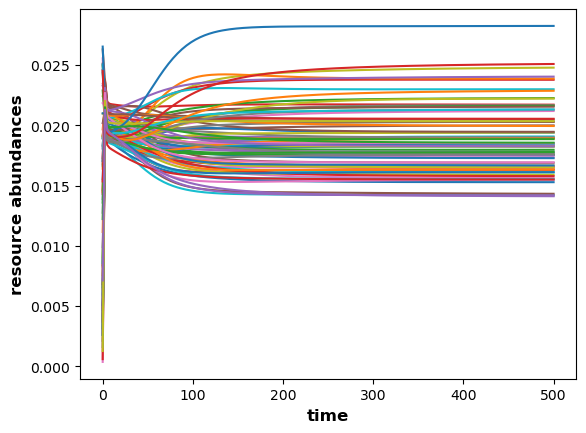

In [13]:
community.simulate_community(t_end = 500, 
                             no_init_cond = 1) # number of initial abundances to simulate from

# plot resource dynamics
plt.plot(community.ODE_sols[0].t,
         community.ODE_sols[0].y[:parameters['M'], :].T) 
plt.xlabel('time', fontsize = 12, weight = "bold")
plt.ylabel('resource abundances', fontsize = 12, weight = "bold")
plt.show()

Note that this code automatically generates initial resource and consumer abundances for you.
You can also supply your own using the following code:

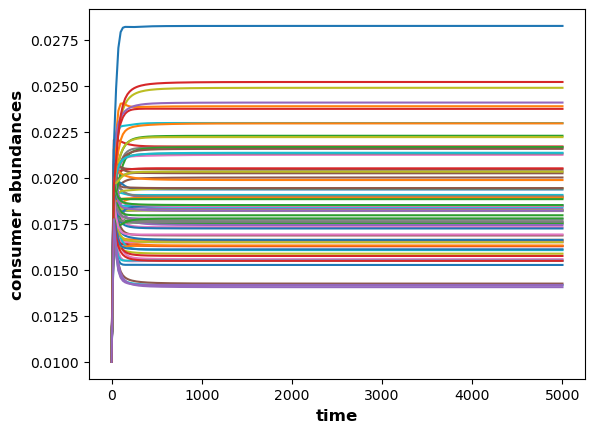

In [14]:
initial_abundances = 0.01*np.ones(parameters['M'] + parameters['S']) # your own initial conditions

community.simulate_community(t_end = 5000, 
                             no_init_cond = 1,
                             init_cond_func='user-supplied',
                             initial_conditions = [initial_abundances]) # must be supplied as a list
# plot resource dynamics
plt.plot(community.ODE_sols[0].t, community.ODE_sols[0].y[:parameters['M'], :].T) 
plt.xlabel('time', fontsize = 12, weight = "bold")
plt.ylabel('consumer abundances', fontsize = 12, weight = "bold")
plt.show()

For details on *simulate_community*, see

In [49]:
print("Simulation: ", community.simulate_community.__doc__)

Simulation:  

Call methods that generate initial abundances and run simulations. 

Parameters
----------
t_end : float
    Simulation end time.
no_init_cond : int
    number of sets of initial abundances to simulate from (no. repeats).
init_cond_func : str, optional
    What function is used to generate the initial conditions. 
    The options: 
        "Mallmin" - Uniform(dispersal, 2/M or S)
        "user supplied" - supply your own intial abundances
    The default is 'Mallmin'.
assign : Bool, optional
    Whether or not to assign simulations as object attributes. True for
    simulations, false for calculating lyapunov exponents. 
    The default is True.
**kwargs : any
    Optional argument for initial condition function. Of the form
    {'user_supplied_init_cond' : {'species' : [initial species abundances],
                                  'resources' : [initial resource abundances]}}

Returns
-------
ODE_sols : list
    list of simulations from n = no_init_cond initial abundan

## Calculate community properties

To automatically calculate community properties, such as the fraction of surviving consumers, average consumer abundance, etc, call *calculate_community_properties method*.

Inspect the community properties as the code shows below.
Note each community property is a list because the property is caculated for each simulation run.

In [15]:
# calculate the consumer and resource survival fractions, average abundances and fluctuations in their abundances at the end of simulations
community.calculate_community_properties()
print("Consumer survival fraction =", community.consumer_survival_fraction, "\n"
      "average abundance =", community.consumer_avg_abundance, "\n"
      "fluctuations in abundance =", community.consumer_abundance_fluctuations, "\n"
      "Resource survival fraction =", community.resource_survival_fraction, "\n"
      "average abundance =", community.resource_avg_abundance, "\n"
      "fluctuations in abundance =", community.resource_abundance_fluctuations)

Consumer survival fraction = [np.float64(0.05405405405405406)] 
average abundance = [np.float64(1.008410779866263)] 
fluctuations in abundance = [np.float64(24.188235273252758)] 
Resource survival fraction = [np.float64(1.0)] 
average abundance = [np.float64(0.01879735629328214)] 
fluctuations in abundance = [np.float64(0.0003615469302712654)]


We determine the stability of each community by numerically estimating its maximum Lyapunov exponent.
The maximum Lyapunov exponent is the largest eigenvalue of the community's Jacobian matrix. 
Therefore, it determines whether community composition is stable in the face of perturbations.

In a continuous-time system, we can define the maximum Lyapunov exponent as follows:
Let's say we have two nearby trajectories of consumer and resource abundances $\mathbf{x}(t)$ in phase space.
The first trajectory is denoted as $\mathbf{x}(t)$ and the nearby trajectory is denoted as $\mathbf{x}(t) + \boldsymbol{\delta}(t)$, where $\boldsymbol{\delta}(0)$ is the initial distance between the trajectories.
In the limit of the initial distance $\boldsymbol{\delta}(0)$ going to zero and the time for which the two trajectories evolve going to $\infty$, we can define the maximum Lyapunov exponent $\lambda_{\max}$ in terms of the long-term distance $\boldsymbol{\delta}(t)$ between the trajectories as:

\begin{align}
\lambda_{\max} = \lim_{\substack{\delta(0) \to 0 \\ \ t \to \infty}} \frac{1}{t} \log\left(\frac{|\boldsymbol{\delta}(t)|}{|\boldsymbol{\delta}(0)|}\right)
\end{align}

We can see that if $\lambda_{\max} < 0$, the absolute distance between trajectories $|\delta(t)|$ decays over time, indicating the system converges at the same stable steady steady.
If $\lambda_{\max} > 0$, the trajectories diverge over time, indicating the system is unstable.
We use this definition to calculate each community's maximum Lyapunov exponent using the following algorithm:

- For each simulation, extract the final consumer and resource abundances from the end of simulations.
- Initialise a "perturbed trajectory" by perturbing the original abundances by some small amount $\boldsymbol{\delta}(0)$ i.e., the Euclidean distance between the original and perturbed trajectory is $\boldsymbol{\delta}(0)$.
- Simulate the dynamics of the original and perturbed trajectory, computing the normalised (log) Euclidean distance between them $\log(\boldsymbol{\delta}(t))$ at each time step. 
- Continue to simulate dynamics until $\log(\boldsymbol{\delta}(t))$ becomes approximately constant.
- To estimate the maximum Lyapunov exponent $\lambda_{\max}$, fit a line to the log distance between trajectories $\log(\boldsymbol{\delta}(t))$ in the region where it varies with time.
- The best-fit slope is the estimated maximum Lyapunov exponent $\lambda_{\max}$. 

Run this code to calculate the exponent ($\boldsymbol{\delta}(0)$ and $t$ are set for you as default arguments):

In [16]:
community.lyapunov_exponent = max_le(community, # model to estimate the exponent for
                                     community.ODE_sols[0].y[:, -1]) # initial abundances/trajectory at t = 0

print("Maximum lyapunov exponent =", community.lyapunov_exponent)

Maximum lyapunov exponent = -0.0032645201271313587
